### Data Loading

In [1]:
import pandas as pd

load_df = pd.read_csv("data/force/f_train.csv")
drop_columns = ['RSHA', 'RMED', 'GR', 'PEF', 'SP', 'ROP', 'DRHO', 'RDEP', 'WELL']
load_df = load_df.drop(drop_columns, axis=1)
load_df = load_df.dropna()
df = load_df.copy()

# Categorize Lithology
litho_code = {30000: "Sandstone", 65030: "SandstoneShale", 65000: "Shale", 80000: "Marl", 
            74000: "Dolomite", 70000: "Limestone", 70032: "Chalk", 88000: "Halite", 
            86000: "Anhydrite", 99000: "Tuff", 90000: "Coal", 93000: "Basement"}
df["LITHOLOGY"] = df["LITHOLOGY"].map(litho_code)

df = df[df.LITHOLOGY != "Shale"]
df = df.reset_index(drop=True)

drop = ['GROUP', 'FORMATION', 'BS']
dt_df = df.drop(drop, axis=1)

# Select sample that Litho is in ['Limestone', 'SandstoneShale']
dt_df = dt_df[dt_df["LITHOLOGY"].isin(["Limestone", "SandstoneShale"])]
dt_df = dt_df.reset_index(drop=True)
dtdfraw = dt_df.copy()
dt_df.head(10)

,DEPTH_MD,CALI,RHOB,NPHI,DTC,LITHOLOGY
0,1151.928,17.363323,2.000440,0.589035,133.393707,SandstoneShale
1,1152.080,17.306395,2.007255,0.595443,135.019684,SandstoneShale
2,1152.232,17.303955,2.017085,0.610448,136.660767,SandstoneShale
3,1152.384,17.368221,2.027622,0.614587,136.615814,SandstoneShale
4,1152.536,17.433296,2.033576,0.600994,134.936020,SandstoneShale
5,1159.376,17.332830,1.993782,0.633213,141.699799,SandstoneShale
6,1159.528,17.305010,1.981597,0.596889,141.424210,SandstoneShale
7,1160.440,17.648685,1.926005,0.550250,140.952103,SandstoneShale
8,1160.592,17.555012,1.899559,0.561272,142.641083,SandstoneShale
9,1168.344,17.534988,2.004711,0.587427,138.450134,SandstoneShale


In [2]:
dt_df[:500].to_csv("data/reg/reg_before.csv", index=False)

#### Convert Label to Binary values and normalize features

In [3]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = dt_df.drop(['LITHOLOGY'], axis=1)
X = scaler.fit_transform(X)
X = pd.DataFrame(X, columns=dt_df.columns[:-1])
dt_df[['DEPTH_MD', 'CALI', 'RHOB', 'NPHI', 'DTC']] = X

le = LabelEncoder()
dt_df['LITHOLOGY'] = le.fit_transform(dt_df['LITHOLOGY'])
dt_df.LITHOLOGY.value_counts()
dt_df.head(10)

,DEPTH_MD,CALI,RHOB,NPHI,DTC,LITHOLOGY
0,-3.228020,2.763317,-2.470029,3.323737,2.653650,1
1,-3.227703,2.741020,-2.433525,3.382617,2.738361,1
2,-3.227386,2.740064,-2.380870,3.520485,2.823859,1
3,-3.227068,2.765235,-2.324432,3.558510,2.821518,1
4,-3.226751,2.790723,-2.292540,3.433618,2.734003,1
5,-3.212473,2.751374,-2.505694,3.729651,3.086386,1
6,-3.212155,2.740477,-2.570963,3.395901,3.072028,1
7,-3.210252,2.875083,-2.868745,2.967387,3.047432,1
8,-3.209934,2.838394,-3.010403,3.068654,3.135425,1
9,-3.193752,2.830552,-2.447153,3.308964,2.917083,1


#### 3D Visualization

In [4]:
# 3D plot using plotly, x: CALI, y: RHOB, z: NPHI, size: DTC, color: LITHOLOGY
import plotly.express as px
import plotly.graph_objects as go
# Change figure size
px.defaults.width = 1000
px.defaults.height = 800
fig = px.scatter_3d(dtdfraw, x='CALI', y='RHOB', z='NPHI', color='LITHOLOGY', size='DTC',
                    color_continuous_scale=px.colors.sequential.Viridis)
fig.update_traces(marker=dict(size=5))
fig.update_layout(scene=dict(xaxis_title='CALI', yaxis_title='RHOB', zaxis_title='NPHI'))
fig.show()


In [5]:
dt_df.head(20)


,DEPTH_MD,CALI,RHOB,NPHI,DTC,LITHOLOGY
0,-3.228020,2.763317,-2.470029,3.323737,2.653650,1
1,-3.227703,2.741020,-2.433525,3.382617,2.738361,1
2,-3.227386,2.740064,-2.380870,3.520485,2.823859,1
3,-3.227068,2.765235,-2.324432,3.558510,2.821518,1
4,-3.226751,2.790723,-2.292540,3.433618,2.734003,1
5,-3.212473,2.751374,-2.505694,3.729651,3.086386,1
6,-3.212155,2.740477,-2.570963,3.395901,3.072028,1
7,-3.210252,2.875083,-2.868745,2.967387,3.047432,1
8,-3.209934,2.838394,-3.010403,3.068654,3.135425,1
9,-3.193752,2.830552,-2.447153,3.308964,2.917083,1


In [6]:
dt_df[:500].to_csv("data/reg/reg_after.csv", index=False)


#### Max-Min Normalization

In [7]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaled_features = scaler.fit_transform(dt_df.drop('LITHOLOGY', axis=1))
scaled_df = pd.DataFrame(scaled_features, columns=dt_df.columns[:-1])
scaled_df['LITHOLOGY'] = dt_df['LITHOLOGY'].values
scaled_df.head()


,DEPTH_MD,CALI,RHOB,NPHI,DTC,LITHOLOGY
0,0.000000,0.609454,0.417278,0.724849,0.697913,1
1,0.000059,0.605952,0.421766,0.733094,0.710956,1
2,0.000118,0.605802,0.428240,0.752399,0.724119,1
3,0.000177,0.609755,0.435180,0.757723,0.723759,1
4,0.000236,0.613757,0.439101,0.740235,0.710284,1


### Train-Test Splitting

In [8]:
from sklearn.model_selection import train_test_split
X = scaled_df.drop('LITHOLOGY', axis=1)
y = scaled_df['LITHOLOGY']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

### Logistic Regression

In [9]:
from sklearn.linear_model import LogisticRegression
log_reg = LogisticRegression(max_iter=500, tol=0.001, random_state=42)
log_reg.fit(X_train, y_train)

LogisticRegression(max_iter=500, random_state=42, tol=0.001)

#### Evaluate the model

In [10]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
y_pred = log_reg.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Logistic Regression Accuracy: {accuracy:.4f}")
print("Classification Report:\n", classification_report(y_test, y_pred))

Logistic Regression Accuracy: 0.9440
Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.93      0.94       505
           1       0.93      0.96      0.94       477

    accuracy                           0.94       982
   macro avg       0.94      0.94      0.94       982
weighted avg       0.94      0.94      0.94       982



#### Confusion Matrix

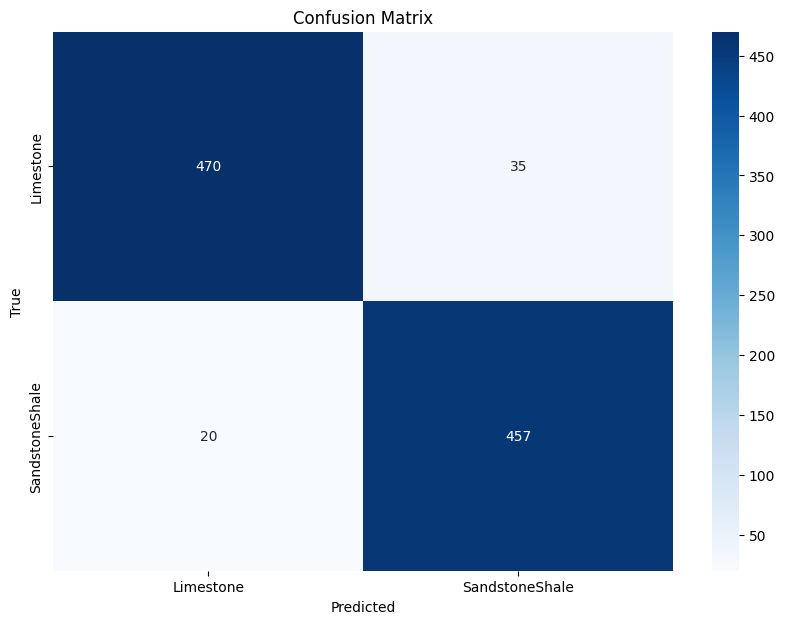

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [12]:
# import seaborn as sns
# import matplotlib.pyplot as plt
# plt.figure(figsize=(8, 6))
# sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', cbar=False)
# plt.xlabel('Predicted')
# plt.ylabel('True')
# plt.title('Confusion Matrix')
# plt.show()


### Multinomial Naive Bayes 

In [13]:
from sklearn.naive_bayes import MultinomialNB
nb = MultinomialNB()
nb.fit(X_train, y_train)
# Evaluation
y_pred_nb = nb.predict(X_test)
accuracy_nb = accuracy_score(y_test, y_pred_nb)
print(f"Multinomial Naive Bayes Accuracy: {accuracy_nb:.4f}")
print("Classification Report:\n", classification_report(y_test, y_pred_nb))

Multinomial Naive Bayes Accuracy: 0.9206
Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.95      0.92       505
           1       0.94      0.89      0.92       477

    accuracy                           0.92       982
   macro avg       0.92      0.92      0.92       982
weighted avg       0.92      0.92      0.92       982



#### Multinomial NB Confusion Matrix

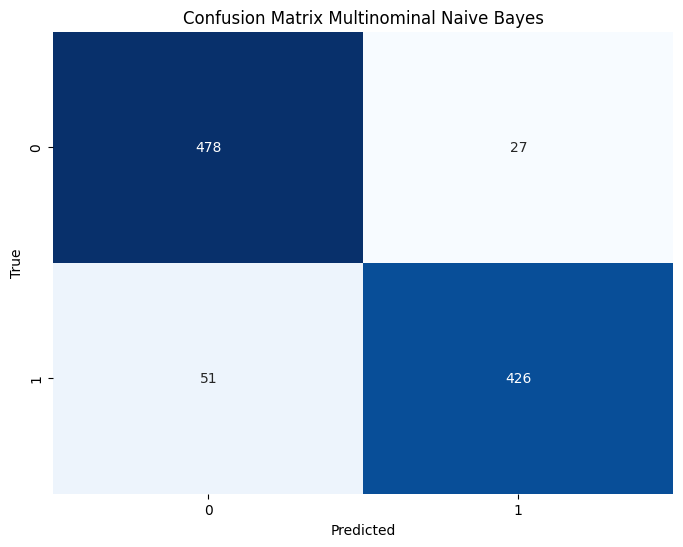

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred_nb), annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix Multinominal Naive Bayes')
plt.show()
